# Chunk Diagnostics
How much did meta-chunking actually kick in vs. passing turns through as-is?

**Three categories per answer turn:**
- **pass-through**: < 10 sentences → meta-chunking never ran, chunk = full turn
- **eligible, unsplit**: ≥ 10 sentences, but meta-chunking found no boundaries → still 1 chunk
- **split**: ≥ 10 sentences, meta-chunking produced > 1 chunk

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

ROOT = Path("..")
CHUNKS_DIR = ROOT / "data" / "csv" / "chunks"
BANKS = ["BoE", "ECB", "Fed"]

In [3]:
def diagnose(bank):
    df = pd.read_csv(CHUNKS_DIR / f"{bank}_chunks.csv")
    answers = df[df["turn_type"] == "answer"].copy()

    # Aggregate to turn level
    turns = (
        answers.groupby(["doc_id", "turn_idx"])
        .agg(total_sents=("n_sentences", "sum"), n_chunks=("chunk_id", "count"))
        .reset_index()
    )

    turns["category"] = np.where(
        turns["total_sents"] < 10, "pass-through",
        np.where(turns["n_chunks"] == 1, "eligible, unsplit", "split")
    )

    n = len(turns)
    cat = turns["category"].value_counts().reindex(["pass-through", "eligible, unsplit", "split"], fill_value=0)

    print(f"\n{'='*46}")
    print(f"  {bank}  -  {n} answer turns")
    print(f"{'='*46}")
    print(f"  {'category':<22} {'N':>6}  {'%':>6}")
    print(f"  {'-'*38}")
    for label, count in cat.items():
        print(f"  {label:<22} {count:>6}  {100*count/n:>5.1f}%")

    eff_full = cat["pass-through"] + cat["eligible, unsplit"]
    print(f"  {'-'*38}")
    print(f"  {'effectively full turns':<22} {eff_full:>6}  {100*eff_full/n:>5.1f}%")

    split_turns = turns[turns["category"] == "split"]
    if len(split_turns):
        print(f"\n  Split turns - chunks per turn:")
        print(f"    mean   {split_turns['n_chunks'].mean():.2f}")
        print(f"    median {split_turns['n_chunks'].median():.1f}")
        print(f"    p75    {split_turns['n_chunks'].quantile(0.75):.1f}")
        print(f"    max    {split_turns['n_chunks'].max()}")

    print(f"\n  Sentence count distribution (all answer turns):")
    for p, v in [(25, turns['total_sents'].quantile(0.25)),
                 (50, turns['total_sents'].median()),
                 (75, turns['total_sents'].quantile(0.75)),
                 (90, turns['total_sents'].quantile(0.90))]:
        print(f"    p{p:<3}  {v:.1f} sents")
    print(f"    max   {turns['total_sents'].max()} sents")

    return turns

results = {bank: diagnose(bank) for bank in BANKS}


  BoE  -  736 answer turns
  category                    N       %
  --------------------------------------
  pass-through              467   63.5%
  eligible, unsplit         266   36.1%
  split                       3    0.4%
  --------------------------------------
  effectively full turns    733   99.6%

  Split turns - chunks per turn:
    mean   2.00
    median 2.0
    p75    2.0
    max    2

  Sentence count distribution (all answer turns):
    p25   4.0 sents
    p50   8.0 sents
    p75   11.0 sents
    p90   15.0 sents
    max   33 sents

  ECB  -  2445 answer turns
  category                    N       %
  --------------------------------------
  pass-through             2317   94.8%
  eligible, unsplit         124    5.1%
  split                       4    0.2%
  --------------------------------------
  effectively full turns   2441   99.8%

  Split turns - chunks per turn:
    mean   2.00
    median 2.0
    p75    2.0
    max    2

  Sentence count distribution (all answe

In [4]:
def summary_table(threshold=10):
    rows = []
    for bank in BANKS:
        df = pd.read_csv(CHUNKS_DIR / f"{bank}_chunks.csv")
        answers = df[df["turn_type"] == "answer"].copy()
        turns = (
            answers.groupby(["doc_id", "turn_idx"])
            .agg(total_sents=("n_sentences", "sum"), n_chunks=("chunk_id", "count"))
            .reset_index()
        )
        n = len(turns)
        pt  = (turns["total_sents"] < threshold).sum()
        spl = (turns["n_chunks"] > 1).sum()
        elig_unsplit = n - pt - spl
        eff = pt + elig_unsplit
        rows.append([bank, f"{100*pt/n:.1f}%", f"{100*elig_unsplit/n:.1f}%", f"{100*spl/n:.1f}%", f"{100*eff/n:.1f}%"])

    cols = ["Bank", f"Pass-through (<{threshold} sents)", "Eligible, unsplit", "Actually split", "Effectively full turns"]
    tbl = pd.DataFrame(rows, columns=cols).set_index("Bank")
    print(f"\nMeta-chunking almost never split answer turns  [threshold={threshold}]")
    print(tbl.to_string())

summary_table(10)
summary_table(8)
summary_table(5)


Meta-chunking almost never split answer turns  [threshold=10]
     Pass-through (<10 sents) Eligible, unsplit Actually split Effectively full turns
Bank                                                                                 
BoE                     63.5%             36.1%           0.4%                  99.6%
ECB                     94.8%              5.1%           0.2%                  99.8%
Fed                     67.4%             32.4%           0.2%                  99.8%

Meta-chunking almost never split answer turns  [threshold=8]
     Pass-through (<8 sents) Eligible, unsplit Actually split Effectively full turns
Bank                                                                                
BoE                    48.4%             51.2%           0.4%                  99.6%
ECB                    87.6%             12.3%           0.2%                  99.8%
Fed                    51.5%             48.4%           0.2%                  99.8%

Meta-chunking almos

## Counterfactual: lower eligibility thresholds\n\nWhat if we lowered the sentence threshold below which meta-chunking runs? Currently it's 10. Below we simulate thresholds of 5 and 8 — showing how many more turns would become eligible and what fraction would still end up unsplit (i.e. chunking ran but found no boundaries).\n\nNote: this is a **lower-bound estimate** of splits. With a lower threshold, the actual meta-chunking signal may be noisier on shorter turns, so real split counts could differ.

In [5]:
def diagnose_threshold(bank, threshold):
    df = pd.read_csv(CHUNKS_DIR / f"{bank}_chunks.csv")
    answers = df[df["turn_type"] == "answer"].copy()

    turns = (
        answers.groupby(["doc_id", "turn_idx"])
        .agg(total_sents=("n_sentences", "sum"), n_chunks=("chunk_id", "count"))
        .reset_index()
    )

    # With a lower threshold, turns previously below 10 would now be eligible.
    # We can't know if they'd split (no re-running embeddings), so we count them
    # as "newly eligible" and show how many currently-split turns we'd add at minimum.
    n = len(turns)
    below_old   = (turns["total_sents"] < 10).sum()
    below_new   = (turns["total_sents"] < threshold).sum()
    newly_eligible = below_old - below_new   # turns that would become eligible

    # Of the already-eligible turns (>= 10 sents), keep split count as-is
    already_split = (turns["n_chunks"] > 1).sum()

    print(f"  {bank:<6}  threshold={threshold}:")
    print(f"    pass-through (< {threshold} sents):   {below_new:>5}  ({100*below_new/n:.1f}%)")
    print(f"    newly eligible vs threshold=10: +{newly_eligible} turns")
    print(f"    currently split (>= 10 sents):  {already_split:>5}  ({100*already_split/n:.1f}%)")
    print()

print("Counterfactual: how many turns become eligible at lower thresholds")
print("(split count shown is only for turns already >= 10 sents)\n")
for threshold in [5, 8]:
    print(f"--- threshold = {threshold} " + "-"*30)
    for bank in BANKS:
        diagnose_threshold(bank, threshold)


Counterfactual: how many turns become eligible at lower thresholds
(split count shown is only for turns already >= 10 sents)

--- threshold = 5 ------------------------------
  BoE     threshold=5:
    pass-through (< 5 sents):     187  (25.4%)
    newly eligible vs threshold=10: +280 turns
    currently split (>= 10 sents):      3  (0.4%)

  ECB     threshold=5:
    pass-through (< 5 sents):    1314  (53.7%)
    newly eligible vs threshold=10: +1003 turns
    currently split (>= 10 sents):      4  (0.2%)

  Fed     threshold=5:
    pass-through (< 5 sents):     422  (23.3%)
    newly eligible vs threshold=10: +800 turns
    currently split (>= 10 sents):      3  (0.2%)

--- threshold = 8 ------------------------------
  BoE     threshold=8:
    pass-through (< 8 sents):     356  (48.4%)
    newly eligible vs threshold=10: +111 turns
    currently split (>= 10 sents):      3  (0.4%)

  ECB     threshold=8:
    pass-through (< 8 sents):    2141  (87.6%)
    newly eligible vs threshold=1

In [6]:
for threshold in [5, 8]:
    rows = []
    for bank in BANKS:
        df = pd.read_csv(CHUNKS_DIR / f"{bank}_chunks.csv")
        answers = df[df["turn_type"] == "answer"].copy()
        turns = (
            answers.groupby(["doc_id", "turn_idx"])
            .agg(total_sents=("n_sentences", "sum"), n_chunks=("chunk_id", "count"))
            .reset_index()
        )
        n = len(turns)
        pt  = (turns["total_sents"] < threshold).sum()
        spl = (turns["n_chunks"] > 1).sum()
        elig_unsplit = n - pt - spl
        eff = pt + elig_unsplit
        rows.append({
            "Bank": bank,
            f"Pass-through (<{threshold} sents)": f"{100*pt/n:.1f}%",
            "Eligible, unsplit":                   f"{100*elig_unsplit/n:.1f}%",
            "Actually split":                      f"{100*spl/n:.1f}%",
            "Effectively full turns":              f"{100*eff/n:.1f}%",
        })

    tbl = pd.DataFrame(rows).set_index("Bank")
    display(
        tbl.style
        .set_caption(f"Counterfactual: threshold = {threshold} sentences")
        .set_table_styles([
            {"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "14px"), ("padding-bottom", "8px")]},
            {"selector": "th", "props": [("background-color", "#2d2d2d"), ("color", "white"), ("text-align", "center"), ("padding", "6px 12px")]},
            {"selector": "td", "props": [("text-align", "center"), ("padding", "5px 12px")]},
            {"selector": "tr:nth-child(even)", "props": [("background-color", "#1e1e1e")]},
        ])
        .map(lambda v: "font-weight: bold; color: #7ec8a0" if float(v.rstrip("%")) > 95 else "", subset=["Effectively full turns"])
    )

,Pass-through (<5 sents),"Eligible, unsplit",Actually split,Effectively full turns
Bank,,,,
BoE,25.4%,74.2%,0.4%,99.6%
ECB,53.7%,46.1%,0.2%,99.8%
Fed,23.3%,76.6%,0.2%,99.8%


,Pass-through (<8 sents),"Eligible, unsplit",Actually split,Effectively full turns
Bank,,,,
BoE,48.4%,51.2%,0.4%,99.6%
ECB,87.6%,12.3%,0.2%,99.8%
Fed,51.5%,48.4%,0.2%,99.8%


## Surprisal sensitivity sweep

The current pipeline almost never splits eligible turns. Two levers control this:

- **`context_window`** — how many sentences on each side are averaged to compute the surprisal score. Smaller = more local, picks up finer-grained topic shifts.
- **`peak_prominence` floor** — the adaptive prominence is `max(floor, signal.std() * 0.5)`. A lower floor lets peaks through in flat signals (like consistent Fed language).

We test 4 combos holding `min_sentences=8`, embedding once and re-running boundary detection in-notebook (no re-encoding per combo):

| Label | context_window | prominence floor |
|---|---|---|
| current | 4 | 0.02 |
| tighter-context | 2 | 0.02 |
| lower-surprise | 4 | 0.005 |
| aggressive | 2 | 0.005 |

**Hypothesis**: Fed press conference answers are semantically flat, so even lower thresholds may not split them. BoE answers (longer, more varied) should respond more to the aggressive setting.

## Longest unsplit turns (current pipeline)

Eligible turns (≥ 10 sentences) that the current chunker left as a single chunk — the cases where the pipeline had the most to work with and still found no boundaries.

In [7]:
N_EXAMPLES  = 3   # per bank
MIN_ELIGIBLE = 10  # matches current pipeline threshold

for bank in BANKS:
    df = pd.read_csv(CHUNKS_DIR / f"{bank}_chunks.csv")
    answers = df[df["turn_type"] == "answer"].copy()

    turns = (
        answers.groupby(["doc_id", "turn_idx"])
        .agg(total_sents=("n_sentences", "sum"), n_chunks=("chunk_id", "count"),
             text=("text", lambda x: " ".join(x)))
        .reset_index()
    )

    unsplit = turns[(turns["total_sents"] >= MIN_ELIGIBLE) & (turns["n_chunks"] == 1)]
    top = unsplit.nlargest(N_EXAMPLES, "total_sents")

    print(f"\n{'='*72}")
    print(f"  {bank}  —  {len(unsplit)} eligible-unsplit turns  |  showing {len(top)} longest")
    print(f"{'='*72}")

    for _, row in top.iterrows():
        print(f"\n  doc: {row['doc_id']}   turn: {row['turn_idx']}   [{row['total_sents']} sents]")
        print(f"  {'-'*68}")
        # wrap text at ~100 chars per line for readability
        import textwrap
        for line in textwrap.wrap(row["text"], width=100):
            print(f"  {line}")
    print()


  BoE  —  266 eligible-unsplit turns  |  showing 3 longest

  doc: BoE_202205_transcript   turn: 14   [33 sents]
  --------------------------------------------------------------------
  As we said, I mean, we have a, sort of, conditioning assumption for energy prices. And we use
  future's curves going out six months and then project then constant thereafter. We do, I should say,
  publish a second version of the forecast, which conditions it on the future's curves throughout.
  And, by the way, I mean, that pushes inflation even further below target at the end point. On your
  very interesting question about well, what's shaping your view of the rest of this year, and what
  are you assuming? Well, in a sense, we are assuming what's in the curves. The way I would interpret
  that is, that that does not embody, for instance, a very sharp effect from, you know, any decision
  to, by the way not just in this country of course, it would be elsewhere in Europe because it's a
  single mark

In [8]:
import sys, os
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
from scipy.signal import find_peaks
from sentence_transformers import SentenceTransformer

# ── config ────────────────────────────────────────────────────────────────────
SENT_DIR  = ROOT / "data" / "csv"
OUT_DIR   = ROOT / "output"
MIN_SENTS = 8

EMBED_CACHE  = OUT_DIR / "diag_sweep_embeddings.npy"   # stacked sentence vecs
META_CACHE   = OUT_DIR / "diag_sweep_meta.csv"          # (bank, doc_id, turn_idx, sent_idx, text)

bank_sent_files = {
    "BoE": SENT_DIR / "BoE_sentence.csv",
    "ECB": SENT_DIR / "ECB_sentence.csv",
    "Fed": SENT_DIR / "Fed_sentence.csv",
}

# ── collect eligible turns ────────────────────────────────────────────────────
eligible_turns = {}   # bank -> list of (doc_id, turn_idx, sents)
meta_rows = []

for bank, path in bank_sent_files.items():
    df = pd.read_csv(path).dropna(subset=["text"])
    answers = df[df["turn_type"] == "answer"].copy()
    turns = []
    for (doc_id, turn_idx), grp in answers.groupby(["doc_id", "turn_idx"]):
        sents = grp.sort_values("sent_idx")["text"].tolist()
        if len(sents) >= MIN_SENTS:
            turns.append((doc_id, turn_idx, sents))
            for s in sents:
                meta_rows.append({"bank": bank, "doc_id": doc_id, "turn_idx": turn_idx, "text": s})
    eligible_turns[bank] = turns
    print(f"{bank}: {len(turns)} eligible turns (>= {MIN_SENTS} sents)")

meta_df = pd.DataFrame(meta_rows).reset_index(drop=True)
all_texts = meta_df["text"].tolist()

# ── embed (or load cache) ─────────────────────────────────────────────────────
OUT_DIR.mkdir(parents=True, exist_ok=True)

if EMBED_CACHE.exists() and META_CACHE.exists():
    cached_meta = pd.read_csv(META_CACHE)
    if list(cached_meta["text"]) == all_texts:
        all_embeddings = np.load(EMBED_CACHE)
        print(f"\nLoaded cached embeddings  {all_embeddings.shape}")
    else:
        print("Cache mismatch — re-embedding...")
        EMBED_CACHE.unlink(missing_ok=True)
        META_CACHE.unlink(missing_ok=True)
else:
    print(f"\nNo cache found — embedding {len(all_texts)} sentences with e5-large-v2...")

if not EMBED_CACHE.exists():
    model = SentenceTransformer("intfloat/e5-large-v2")
    prefixed = [f"passage: {t}" for t in all_texts]
    all_embeddings = model.encode(prefixed, normalize_embeddings=True,
                                  batch_size=256, show_progress_bar=True)
    np.save(EMBED_CACHE, all_embeddings)
    meta_df.to_csv(META_CACHE, index=False)
    print(f"Saved → {EMBED_CACHE}  {all_embeddings.shape}")

# ── reconstruct per-turn embedding lists ─────────────────────────────────────
# Build an index from (bank, doc_id, turn_idx) → slice of all_embeddings
meta_df["_emb_idx"] = meta_df.index

turn_embeddings = {}  # bank -> list of np.ndarray, aligned with eligible_turns[bank]
for bank, turns in eligible_turns.items():
    bank_meta = meta_df[meta_df["bank"] == bank]
    embs = []
    for doc_id, turn_idx, sents in turns:
        idxs = bank_meta[
            (bank_meta["doc_id"] == doc_id) & (bank_meta["turn_idx"] == turn_idx)
        ]["_emb_idx"].values
        embs.append(all_embeddings[idxs])
    turn_embeddings[bank] = embs

print("\nReady. Embeddings indexed per turn for all banks.")

BoE: 380 eligible turns (>= 8 sents)
ECB: 304 eligible turns (>= 8 sents)
Fed: 880 eligible turns (>= 8 sents)

Loaded cached embeddings  (18578, 1024)

Ready. Embeddings indexed per turn for all banks.


,Config,ctx_window,prom_floor,BoE — Mean chunks,ECB — Mean chunks,Fed — Mean chunks,BoE — Split %,ECB — Split %,Fed — Split %
0,aggressive,2,0.005000,1.28,1.17,1.27,25.3%,13.8%,23.6%
1,current,4,0.020000,1.01,1.01,1.00,0.8%,1.3%,0.3%
2,lower-surprise,4,0.005000,1.05,1.04,1.06,5.0%,3.6%,5.1%
3,tighter-ctx,2,0.020000,1.08,1.06,1.08,7.9%,5.6%,7.3%


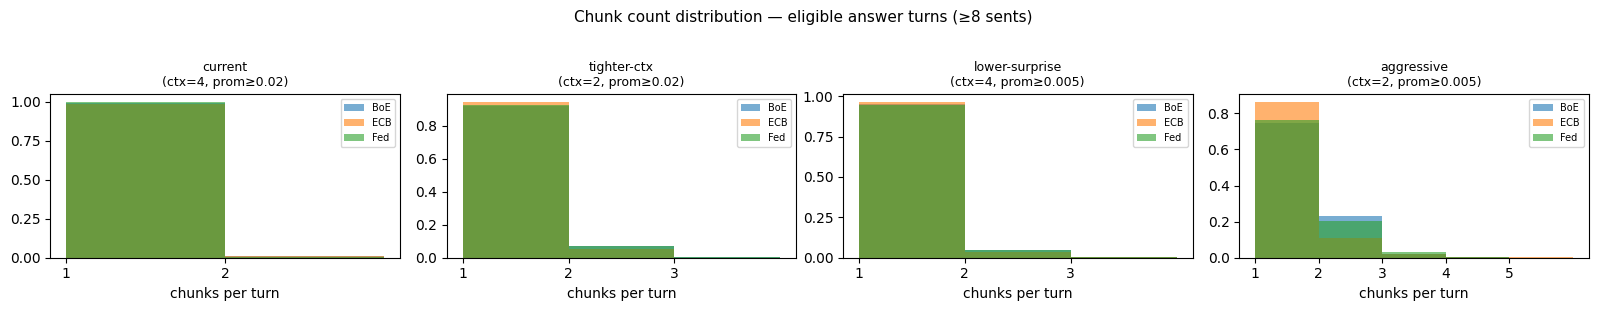

In [9]:
import matplotlib.pyplot as plt

# ── boundary detection helpers (mirrors chunking_corpus.py) ──────────────────

def window_surprisal(embeddings, window):
    scores = np.zeros(len(embeddings))
    for i in range(window, len(embeddings) - window):
        left  = embeddings[i - window : i]
        right = embeddings[i : i + window]
        scores[i] = 1 - np.dot(left.mean(0), right.mean(0))
    return scores

def smooth(signal, window=4):
    return np.convolve(signal, np.ones(window) / window, mode="valid")

def count_splits(embeddings, context_window, smooth_window, prominence_floor):
    """Return number of chunks for a single turn (1 = unsplit)."""
    n = len(embeddings)
    if n < 2 * context_window + 1:
        return 1
    surprisal = window_surprisal(embeddings, context_window)
    interior  = surprisal[context_window : n - context_window]
    sig       = smooth(interior, smooth_window)
    prom      = max(prominence_floor, sig.std() * 0.5)
    peaks, _  = find_peaks(sig, prominence=prom)
    return len(peaks) + 1  # n boundaries → n+1 chunks

# ── parameter grid ────────────────────────────────────────────────────────────

COMBOS = [
    ("current",        4, 0.02),
    ("tighter-ctx",    2, 0.02),
    ("lower-surprise", 4, 0.005),
    ("aggressive",     2, 0.005),
]
SMOOTH_WINDOW = 4  # unchanged across all combos

# ── sweep ─────────────────────────────────────────────────────────────────────

rows = []
detail = {}  # label -> bank -> list of n_chunks

for label, cw, pf in COMBOS:
    detail[label] = {}
    for bank in BANKS:
        turns = eligible_turns[bank]
        embs  = turn_embeddings[bank]
        n_chunks_list = [
            count_splits(e, cw, SMOOTH_WINDOW, pf)
            for e in embs
        ]
        detail[label][bank] = n_chunks_list
        n         = len(turns)
        n_split   = sum(c > 1 for c in n_chunks_list)
        mean_c    = np.mean(n_chunks_list)
        rows.append({
            "Config":     label,
            "ctx_window": cw,
            "prom_floor": pf,
            "Bank":       bank,
            "Eligible N": n,
            "Split":      n_split,
            "Split %":    f"{100 * n_split / n:.1f}%",
            "Mean chunks": f"{mean_c:.2f}",
        })

sweep_df = pd.DataFrame(rows)

# ── display as pivot ──────────────────────────────────────────────────────────

pivot = sweep_df.pivot_table(
    index=["Config", "ctx_window", "prom_floor"],
    columns="Bank",
    values=["Split %", "Mean chunks"],
    aggfunc="first"
)
# Flatten multi-level columns
pivot.columns = [f"{bank} — {stat}" for stat, bank in pivot.columns]
pivot = pivot.reset_index()

display(pivot.style
    .set_caption("Surprisal sensitivity sweep  [min_sentences=8, smooth_window=4]")
    .set_table_styles([
        {"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "14px"), ("padding-bottom", "8px")]},
        {"selector": "th",      "props": [("background-color", "#2d2d2d"), ("color", "white"), ("padding", "6px 10px")]},
        {"selector": "td",      "props": [("text-align", "center"), ("padding", "5px 10px")]},
        {"selector": "tr:nth-child(even)", "props": [("background-color", "#1e1e1e")]},
    ])
)

# ── histogram of chunks per turn for each combo ───────────────────────────────

fig, axes = plt.subplots(1, len(COMBOS), figsize=(16, 3), sharey=False)
for ax, (label, cw, pf) in zip(axes, COMBOS):
    for bank in BANKS:
        vals = detail[label][bank]
        ax.hist(vals, bins=range(1, max(vals) + 2), alpha=0.6, label=bank, density=True)
    ax.set_title(f"{label}\n(ctx={cw}, prom≥{pf})", fontsize=9)
    ax.set_xlabel("chunks per turn")
    ax.legend(fontsize=7)
    ax.set_xticks(range(1, max(max(detail[label][b]) for b in BANKS) + 1))
fig.suptitle("Chunk count distribution — eligible answer turns (≥8 sents)", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# ── Qualitative check: where do splits land in long Fed answers? ──────────────
# For the "aggressive" config (most splits), show the top-N longest Fed turns
# that get split, printing sentences with boundary markers.

QUAL_COMBO  = "aggressive"
QUAL_CW, QUAL_PF = 2, 0.005
N_EXAMPLES  = 5

fed_turns = eligible_turns["Fed"]
fed_embs  = turn_embeddings["Fed"]

# Pick longest turns that would be split under aggressive settings
scored = []
for i, ((doc_id, turn_idx, sents), embs) in enumerate(zip(fed_turns, fed_embs)):
    n_c = count_splits(embs, QUAL_CW, SMOOTH_WINDOW, QUAL_PF)
    if n_c > 1:
        scored.append((len(sents), i, doc_id, turn_idx, sents, embs, n_c))

scored.sort(reverse=True)  # longest first

print(f"Fed turns split under '{QUAL_COMBO}' (ctx={QUAL_CW}, prom≥{QUAL_PF}): {len(scored)} total\n")
print("=" * 72)

for _, i, doc_id, turn_idx, sents, embs, n_c in scored[:N_EXAMPLES]:
    # Re-detect boundaries to get positions
    surprisal = window_surprisal(embs, QUAL_CW)
    interior  = surprisal[QUAL_CW : len(embs) - QUAL_CW]
    sig       = smooth(interior, SMOOTH_WINDOW)
    prom      = max(QUAL_PF, sig.std() * 0.5)
    peaks, _  = find_peaks(sig, prominence=prom)
    offset    = QUAL_CW + (SMOOTH_WINDOW - 1) // 2
    boundary_set = {p + offset for p in peaks}

    print(f"\n{doc_id}  turn {turn_idx}  [{len(sents)} sents → {n_c} chunks]")
    print("-" * 72)
    for j, sent in enumerate(sents):
        prefix = ">>> BOUNDARY >>>" if j in boundary_set else f"  [{j:02d}]"
        print(f"{prefix}  {sent[:120]}")
    print("=" * 72)

Fed turns split under 'aggressive' (ctx=2, prom≥0.005): 208 total


FOMCpresconf20200729  turn 44  [35 sents → 3 chunks]
------------------------------------------------------------------------
  [00]  And we always point this out in our-in our remarks.
  [01]  While the aggregate unemployment rate was 3½ percent, every-every economy-every market in every economy has longer-run i
  [02]  And one of ours is just the disparate level of unemployment between-between Blacks and whites.
  [03]  And it's generally sort of twice as much-twice as high for Blacks.
  [04]  So even-but this was the lowest, you know, Black unemployment rate in 50 years-or, actually, since we started keeping re
  [05]  So that's just a fact, and it's-it's not a good fact, you know.
  [06]  So we have started, though, in recent years to focus considerable time and attention on disparate levels of unemployment
  [07]  We call them out in testimony and in speeches and in our Monetary Policy Report to Congress.
>>> BOUN

In [11]:
N_EXAMPLES  = 3   # per bank
MIN_ELIGIBLE = 10  # matches current pipeline threshold

for bank in BANKS:
    df = pd.read_csv(CHUNKS_DIR / f"{bank}_chunks.csv")
    answers = df[df["turn_type"] == "answer"].copy()

    turns = (
        answers.groupby(["doc_id", "turn_idx"])
        .agg(total_sents=("n_sentences", "sum"), n_chunks=("chunk_id", "count"),
             text=("text", lambda x: " ".join(x)))
        .reset_index()
    )

    unsplit = turns[(turns["total_sents"] >= MIN_ELIGIBLE) & (turns["n_chunks"] == 1)]
    top = unsplit.nlargest(N_EXAMPLES, "total_sents")

    print(f"\n{'='*72}")
    print(f"  {bank}  —  {len(unsplit)} eligible-unsplit turns  |  showing {len(top)} longest")
    print(f"{'='*72}")

    for _, row in top.iterrows():
        print(f"\n  doc: {row['doc_id']}   turn: {row['turn_idx']}   [{row['total_sents']} sents]")
        print(f"  {'-'*68}")
        import textwrap
        for line in textwrap.wrap(row["text"], width=100):
            print(f"  {line}")
    print()



  BoE  —  266 eligible-unsplit turns  |  showing 3 longest

  doc: BoE_202205_transcript   turn: 14   [33 sents]
  --------------------------------------------------------------------
  As we said, I mean, we have a, sort of, conditioning assumption for energy prices. And we use
  future's curves going out six months and then project then constant thereafter. We do, I should say,
  publish a second version of the forecast, which conditions it on the future's curves throughout.
  And, by the way, I mean, that pushes inflation even further below target at the end point. On your
  very interesting question about well, what's shaping your view of the rest of this year, and what
  are you assuming? Well, in a sense, we are assuming what's in the curves. The way I would interpret
  that is, that that does not embody, for instance, a very sharp effect from, you know, any decision
  to, by the way not just in this country of course, it would be elsewhere in Europe because it's a
  single mark